# Tree-Based Models — Flight Delay Prediction
## Miami International Airport (MIA) | January–February 2024

This notebook builds and compares three classification models to predict whether a flight will experience a **significant delay (> 15 minutes)**:

- **Decision Tree Classifier** — interpretable, rule-based model
- **Random Forest Classifier** — ensemble model with feature importance
- **XGBoost Classifier** — gradient boosting model for improved accuracy

Due to extreme class imbalance in cancellations, we redefined the problem to predict **flight delays (>15 minutes)**.

We ensure no data leakage by excluding variables directly used to construct the target.

**Feature importance is further analyzed using SHAP (SHapley Additive exPlanations)** to provide a robust and model-agnostic explanation of each variable's contribution.

In [1]:
# =====================================================
#  IMPORTS
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import sys
sys.path.append('..')
from my_modules.model_utils import (
    load_clean_data,
    build_features,
    build_target,
    get_train_test_split,
    evaluate_model,
    get_metrics,
    plot_confusion_matrix,
    overfit_report,
    build_decile_summary,
    compute_shap_values,
    plot_shap_summary
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
FEATURES = [
    'month', 'day_of_week', 'dep_hour',
    'distance', 'is_peak', 'is_weekend', 'is_early_morning'
]
TARGET = 'is_delayed'

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading and Feature Engineering

We load the cleaned MIA flight dataset and engineer several time-based and distance-based features that may help the models identify patterns associated with delays.

In [2]:
# =====================================================
# LOAD CLEANED DATA
# =====================================================
df = load_clean_data('../data/processed/mia_flights_clean.csv')
df = build_features(df)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (19396, 24)


,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,...,air_time,distance,weather_delay,late_aircraft_delay,dep_hour,time_of_day,is_peak,is_weekend,is_early_morning,distance_bucket
0,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,1758.0,34.0,...,100.0,700,0,0,17,2,1,0,0,1
1,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2042.0,16.0,...,89.0,594,0,87,20,3,0,0,0,1
2,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,840.0,20.0,...,90.0,594,0,0,8,1,1,0,0,1
3,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2111.0,17.0,...,164.0,1258,0,0,21,3,0,0,0,1
4,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2159.0,28.0,...,100.0,650,0,0,21,3,0,0,0,1


## 2. Target Variable — Delay Definition

A flight is labeled as **delayed** if its `late_aircraft_delay` exceeds 15 minutes. This threshold aligns with the FAA's standard definition of a significant delay. Flights with missing values in this field are excluded from the modeling dataset.

In [3]:
# =====================================================
# TARGET VARIABLE
# =====================================================
df = build_target(df, threshold=15)

print("Class distribution:")
print(df['is_delayed'].value_counts())
print(f"\nDelay rate: {df['is_delayed'].mean():.2%}")

Class distribution:
is_delayed
0    17181
1     2215
Name: count, dtype: int64

Delay rate: 11.42%


## 3. Feature Selection

The following features were selected based on domain knowledge and availability at prediction time (no post-departure information is used, avoiding data leakage):

| Feature | Description |
|---|---|
| `month` | Month of the flight (seasonality) |
| `day_of_week` | Day of week (traffic patterns) |
| `dep_hour` | Departure hour (congestion effects) |
| `distance` | Route distance in miles |
| `is_peak` | Whether flight departs during peak hours |
| `is_weekend` | Whether flight is on a weekend |
| `is_early_morning` | Whether flight departs before 8 AM |

In [4]:
# =====================================================
# FEATURE SELECTION & DATASET SHAPE
# =====================================================
model_df = df[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES]
y = model_df[TARGET]

print("Final dataset shape:", model_df.shape)
print("\nFeature dtypes:")
print(X.dtypes)

Final dataset shape: (19396, 8)

Feature dtypes:
month               int64
day_of_week         int64
dep_hour            int64
distance            int64
is_peak             int64
is_weekend          int64
is_early_morning    int64
dtype: object


## 4. Train / Test Split

We use an 80/20 stratified split to preserve the class ratio in both subsets, given the imbalanced nature of the target variable.

In [5]:
# =====================================================
# TRAIN / TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = get_train_test_split(
    df, FEATURES, TARGET,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Train delay rate: {y_train.mean():.2%}")
print(f"Test delay rate:  {y_test.mean():.2%}")

Train size: 15,516
Test size:  3,880
Train delay rate: 11.42%
Test delay rate:  11.42%


## 5. Model Training

### 5.1 Decision Tree Classifier

The Decision Tree is an interpretable baseline model that splits data based on feature thresholds. It is prone to overfitting but provides a useful reference point.

In [6]:
# =====================================================
# DECISION TREE
# =====================================================
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]
auc_dt    = roc_auc_score(y_test, y_prob_dt)

evaluate_model("Decision Tree", dt, X_test, y_test)

Decision Tree — Classification Report
              precision    recall  f1-score   support

     On Time       0.90      0.96      0.93      3437
     Delayed       0.38      0.20      0.27       443

    accuracy                           0.87      3880
   macro avg       0.64      0.58      0.60      3880
weighted avg       0.84      0.87      0.85      3880



**Figure 1 — Decision Tree Confusion Matrix**

The confusion matrix below shows the counts of true positives, true negatives, false positives, and false negatives produced by the Decision Tree on the test set. A high number of false negatives indicates the model misses many actual delays.

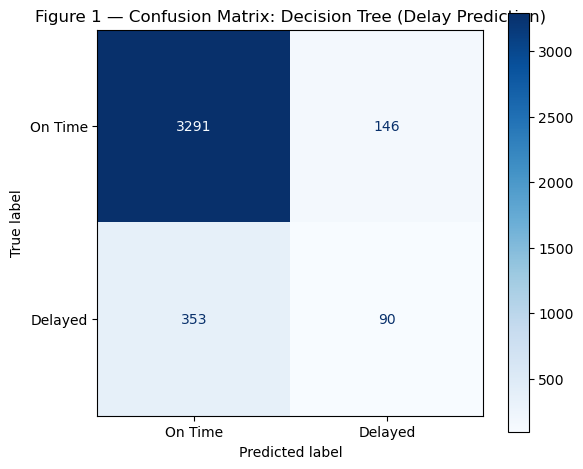

In [7]:
# =====================================================
# DECISION TREE — CONFUSION MATRIX (Figure 1)
# =====================================================
plot_confusion_matrix(
    dt, X_test, y_test,
    title="Figure 1 — Confusion Matrix: Decision Tree (Delay Prediction)",
    cmap="Blues",
    save_path="../outputs/confusion_matrix_dt_delay.png"
)

**Figure 2 — Decision Tree Structure (First 3 Levels)**

The tree visualization below shows the first three levels of the Decision Tree. Each node displays the splitting feature, threshold, Gini impurity, and sample counts. This provides interpretable decision rules for predicting flight delays.

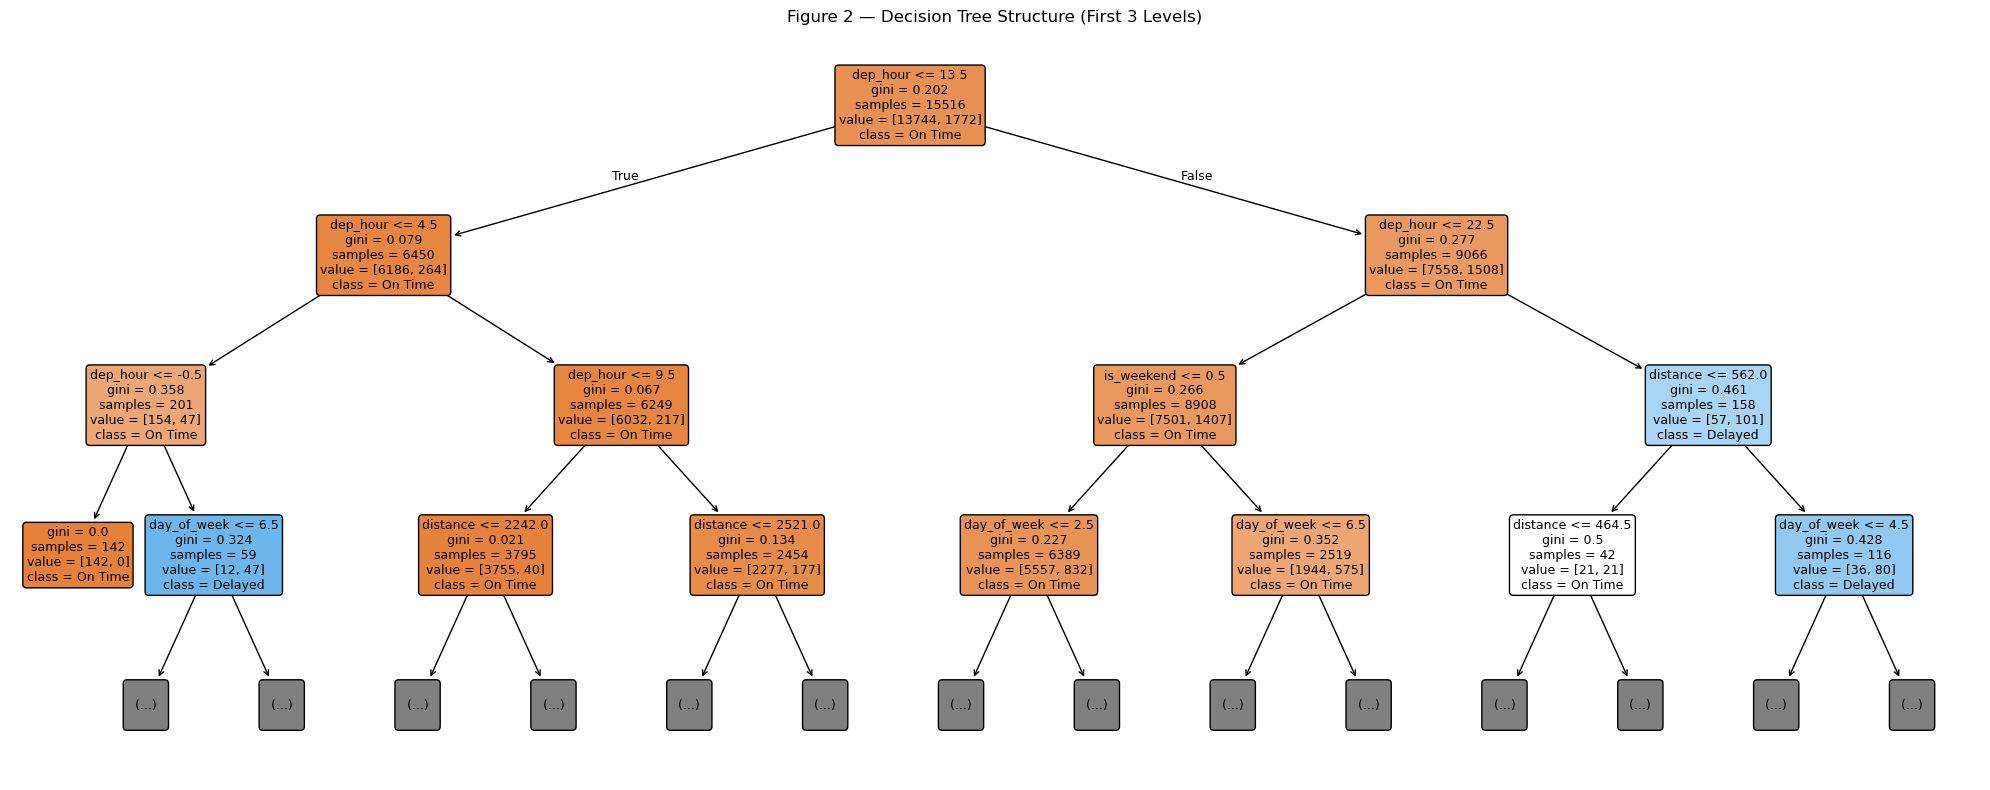

In [11]:
# =====================================================
# DECISION TREE — VISUALIZATION (Figure 2)
# =====================================================
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt, max_depth=3,
    feature_names=FEATURES,
    class_names=['On Time', 'Delayed'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Figure 2 — Decision Tree Structure (First 3 Levels)")
plt.tight_layout()
plt.savefig('../outputs/decision_tree_delay.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Random Forest Classifier

The Random Forest is an ensemble of decision trees trained on random subsets of the data and features. It reduces variance through averaging and handles class imbalance via `class_weight='balanced'`.

In [8]:
# =====================================================
# RANDOM FOREST
# =====================================================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

evaluate_model("Random Forest", rf, X_test, y_test)

Random Forest — Classification Report
              precision    recall  f1-score   support

     On Time       0.93      0.73      0.82      3437
     Delayed       0.22      0.60      0.32       443

    accuracy                           0.72      3880
   macro avg       0.58      0.67      0.57      3880
weighted avg       0.85      0.72      0.76      3880



**Figure 3 — Random Forest Confusion Matrix**

Compared to Figure 1, the Random Forest confusion matrix shows improved recall for the delayed class, meaning the model captures more actual delays at the cost of some additional false positives.

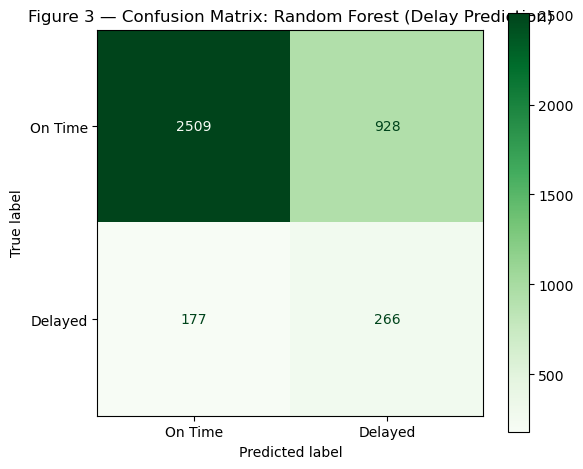

In [9]:
# =====================================================
# RANDOM FOREST — CONFUSION MATRIX (Figure 3)
# =====================================================
plot_confusion_matrix(
    rf, X_test, y_test,
    title="Figure 3 — Confusion Matrix: Random Forest (Delay Prediction)",
    cmap="Greens",
    save_path="../outputs/confusion_matrix_rf_delay.png"
)

### 5.3 XGBoost Classifier

XGBoost (Extreme Gradient Boosting) builds trees sequentially, where each tree corrects the errors of the previous one. We use `scale_pos_weight` to address class imbalance, setting it to the ratio of negative to positive samples in the training set.

In [10]:
# =====================================================
# XGBOOST
# =====================================================
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)

print(f"scale_pos_weight used: {scale_pos:.2f}")
evaluate_model("XGBoost", xgb, X_test, y_test)

scale_pos_weight used: 7.76
XGBoost — Classification Report
              precision    recall  f1-score   support

     On Time       0.94      0.75      0.83      3437
     Delayed       0.25      0.64      0.36       443

    accuracy                           0.74      3880
   macro avg       0.60      0.70      0.60      3880
weighted avg       0.86      0.74      0.78      3880



**Figure 4 — XGBoost Confusion Matrix**

The XGBoost confusion matrix shows how gradient boosting compares to the tree-based models above. XGBoost tends to reduce false negatives further by learning from previous misclassifications in each boosting round.

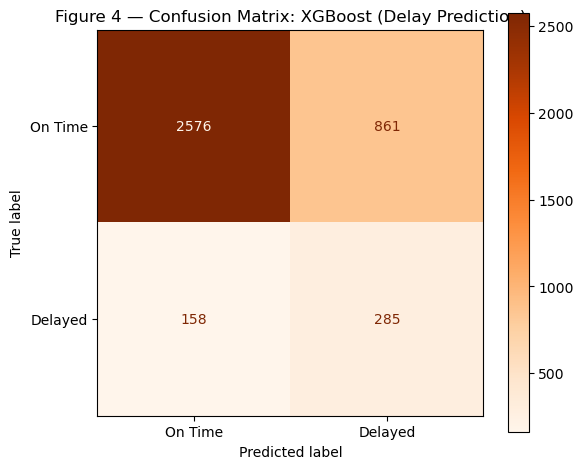

In [11]:
# =====================================================
# XGBOOST — CONFUSION MATRIX (Figure 4)
# =====================================================
plot_confusion_matrix(
    xgb, X_test, y_test,
    title="Figure 4 — Confusion Matrix: XGBoost (Delay Prediction)",
    cmap="Oranges",
    save_path="../outputs/confusion_matrix_xgb_delay.png"
)

## 6. Hyperparameter Tuning — Random Forest

We perform a grid search over key Random Forest hyperparameters to find the configuration that maximizes ROC-AUC on 5-fold cross-validation.

In [17]:
# =====================================================
# HYPERPARAMETER TUNING — RANDOM FOREST
# =====================================================
rf_param_grid = {
    'max_depth': [5, 10, 15, None],
    'n_estimators': [100, 200, 300]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, refit=True
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best CV ROC-AUC:", round(rf_grid.best_score_, 4))

best_rf         = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
cv_rf_tuned     = rf_grid.best_score_

Best RF params: {'max_depth': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.7897


## 7. Cross-Validation

We evaluate all four models using 5-fold stratified cross-validation. This gives a more reliable estimate of generalization performance than a single train/test split.

In [18]:
# =====================================================
# CROSS-VALIDATION
# =====================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_dt  = cross_val_score(dt,  X, y, cv=cv, scoring='roc_auc')
cv_rf  = cross_val_score(rf,  X, y, cv=cv, scoring='roc_auc')
cv_xgb = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

print("5-Fold Stratified Cross-Validation (ROC-AUC)")
print("=" * 50)
print(f"Decision Tree:       {cv_dt.mean():.4f}  (+/- {cv_dt.std():.4f})")
print(f"Random Forest:       {cv_rf.mean():.4f}  (+/- {cv_rf.std():.4f})")
print(f"Tuned Random Forest: {cv_rf_tuned:.4f}")
print(f"XGBoost:             {cv_xgb.mean():.4f} (+/- {cv_xgb.std():.4f})")

5-Fold Stratified Cross-Validation (ROC-AUC)
Decision Tree:       0.6401  (+/- 0.0069)
Random Forest:       0.7689  (+/- 0.0098)
Tuned Random Forest: 0.7897
XGBoost:             0.8079 (+/- 0.0062)


## 8. Overfitting Check

We compare train vs. test accuracy for each model. A gap greater than 10% indicates overfitting.

In [19]:
# =====================================================
# OVERFITTING CHECK
# =====================================================
overfit_report("Decision Tree", dt,      X_train, X_test, y_train, y_test)
overfit_report("Random Forest", rf,      X_train, X_test, y_train, y_test)
overfit_report("Tuned RF",      best_rf, X_train, X_test, y_train, y_test)
overfit_report("XGBoost",       xgb,     X_train, X_test, y_train, y_test)


Decision Tree
  Train Accuracy : 0.939
  Test  Accuracy : 0.871
  Gap            : 0.068 ✅ Good generalization

Random Forest
  Train Accuracy : 0.766
  Test  Accuracy : 0.715
  Gap            : 0.050 ✅ Good generalization

Tuned RF
  Train Accuracy : 0.900
  Test  Accuracy : 0.890
  Gap            : 0.010 ✅ Good generalization

XGBoost
  Train Accuracy : 0.789
  Test  Accuracy : 0.737
  Gap            : 0.051 ✅ Good generalization


## 9. ROC Curves — All Models

**Figure 5 — ROC Curves**

The ROC curve plots the True Positive Rate against the False Positive Rate at various thresholds. A higher AUC indicates better discrimination between delayed and on-time flights. The diagonal dashed line represents a random classifier (AUC = 0.50).

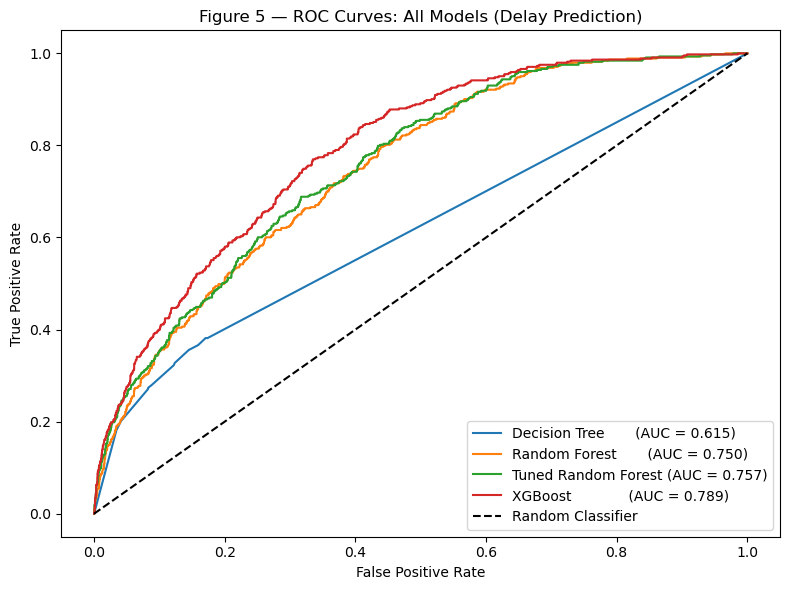

In [20]:
# =====================================================
# ROC CURVES — ALL MODELS (Figure 5)
# =====================================================
auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

fpr_dt,       tpr_dt,       _ = roc_curve(y_test, y_prob_dt)
fpr_rf,       tpr_rf,       _ = roc_curve(y_test, y_prob_rf)
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
fpr_xgb,      tpr_xgb,      _ = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_dt,       tpr_dt,       label=f"Decision Tree       (AUC = {auc_dt:.3f})")
ax.plot(fpr_rf,       tpr_rf,       label=f"Random Forest       (AUC = {auc_rf:.3f})")
ax.plot(fpr_rf_tuned, tpr_rf_tuned, label=f"Tuned Random Forest (AUC = {auc_rf_tuned:.3f})")
ax.plot(fpr_xgb,      tpr_xgb,      label=f"XGBoost             (AUC = {auc_xgb:.3f})")
ax.plot([0,1], [0,1], 'k--', label='Random Classifier')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 5 — ROC Curves: All Models (Delay Prediction)")
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curve_delay.png', dpi=150)
plt.show()

## 10. Model Comparison Table

**Table 1 — Model Performance Summary**

The table below consolidates key metrics for all models on the held-out test set:
- **Precision**: Of all predicted delays, what fraction were real?
- **Recall**: Of all real delays, what fraction did the model catch?
- **F1**: Harmonic mean of precision and recall.
- **ROC-AUC**: Overall discrimination power.

In [21]:
# =====================================================
# MODEL COMPARISON TABLE (Table 1)
# =====================================================
import pandas as pd

models = {
    'Decision Tree':        (dt,      y_pred_dt,       auc_dt,       cv_dt.mean()),
    'Random Forest':        (rf,      y_pred_rf,       auc_rf,       cv_rf.mean()),
    'Tuned Random Forest':  (best_rf, y_pred_rf_tuned, auc_rf_tuned, cv_rf_tuned),
    'XGBoost':              (xgb,     y_pred_xgb,      auc_xgb,      cv_xgb.mean()),
}

rows = []
for name, (model, _, auc_test, auc_cv) in models.items():
    m = get_metrics(model, X_test, y_test)
    rows.append({
        'Model':               name,
        'Accuracy':            m['accuracy'],
        'Precision (delayed)': m['precision'],
        'Recall (delayed)':    m['recall'],
        'F1 (delayed)':        m['f1'],
        'ROC-AUC (test)':      m['roc_auc'],
        'CV ROC-AUC (mean)':   round(auc_cv, 4),
    })

results = pd.DataFrame(rows).set_index('Model')

print("Table 1 — Model Performance Summary")
print("=" * 70)
print(results.to_string())

results.to_csv('../outputs/tree_model_comparison_delay.csv')
print("\nSaved to outputs/tree_model_comparison_delay.csv")

Table 1 — Model Performance Summary
                     Accuracy  Precision (delayed)  Recall (delayed)  F1 (delayed)  ROC-AUC (test)  CV ROC-AUC (mean)
Model                                                                                                                
Decision Tree          0.8714               0.3814            0.2032        0.2651          0.6151             0.6401
Random Forest          0.7152               0.2228            0.6005        0.3250          0.7501             0.7689
Tuned Random Forest    0.8897               0.6316            0.0813        0.1440          0.7575             0.7897
XGBoost                0.7374               0.2487            0.6433        0.3587          0.7891             0.8079

Saved to outputs/tree_model_comparison_delay.csv


## 11. Feature Importance — Random Forest (MDI)

**Figure 6 — Random Forest Feature Importance (MDI)**

Mean Decrease in Impurity (MDI) measures how much each feature reduces uncertainty across all trees. Note that MDI can be biased toward high-cardinality features; SHAP values in Section 12 provide a more reliable alternative.

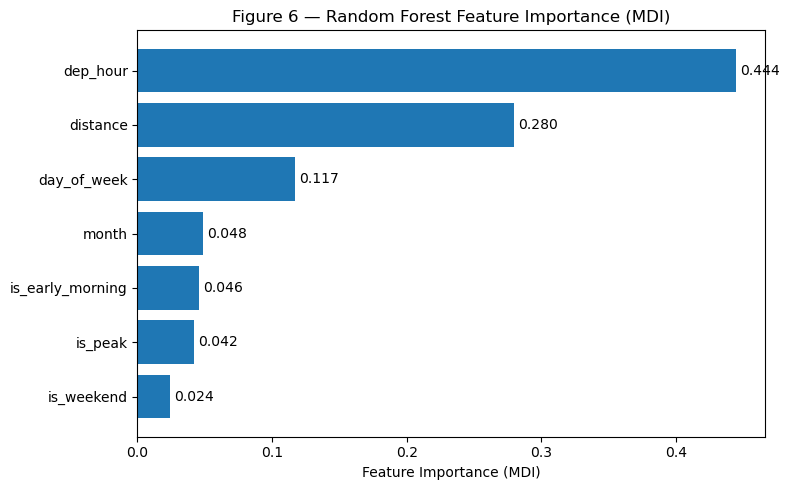

In [22]:
# =====================================================
# FEATURE IMPORTANCE — RF MDI (Figure 6)
# =====================================================
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title("Figure 6 — Random Forest Feature Importance (MDI)")
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('../outputs/feature_importance_delay.png', dpi=150)
plt.show()

## 12. SHAP — Feature Importance Analysis

SHAP (SHapley Additive exPlanations) provides a unified, game-theory-based measure of feature importance. Unlike MDI, SHAP values account for feature interactions, show the direction of each feature's effect, and are consistent across observations.

### 12.1 SHAP — Random Forest

**Figure 7 — SHAP Summary Plot (Random Forest)**

Each dot is one observation. The x-axis shows the SHAP value (impact on model output). Color indicates the feature value (red = high, blue = low). Features are ranked top-to-bottom by mean absolute SHAP value.

<Figure size 1000x600 with 0 Axes>

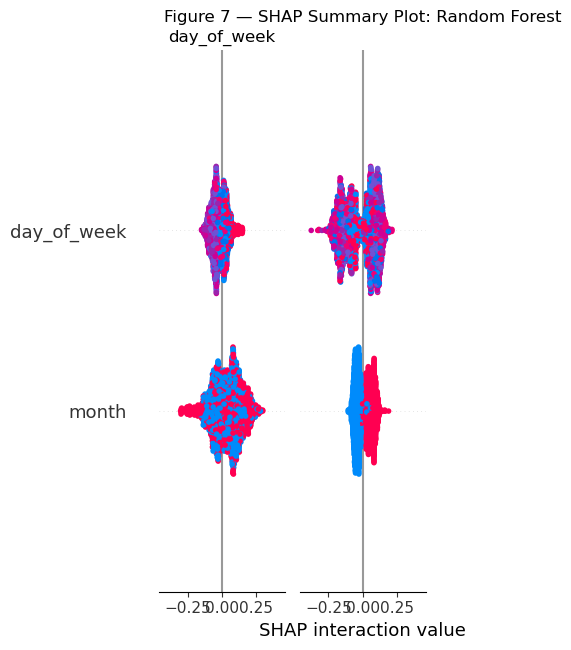

In [23]:
# =====================================================
# SHAP — RANDOM FOREST (Figure 7)
# =====================================================
_, sv_rf = compute_shap_values(rf, X_test)

plot_shap_summary(
    sv_rf, X_test,
    title="Figure 7 — SHAP Summary Plot: Random Forest",
    plot_type="dot",
    save_path="../outputs/shap_summary_rf.png"
)

**Figure 8 — SHAP Mean Absolute Importance (Random Forest)**

This bar chart shows the average absolute SHAP value per feature — a global, unbiased importance measure. Features with higher mean |SHAP| have a larger overall influence on predictions.

<Figure size 1000x600 with 0 Axes>

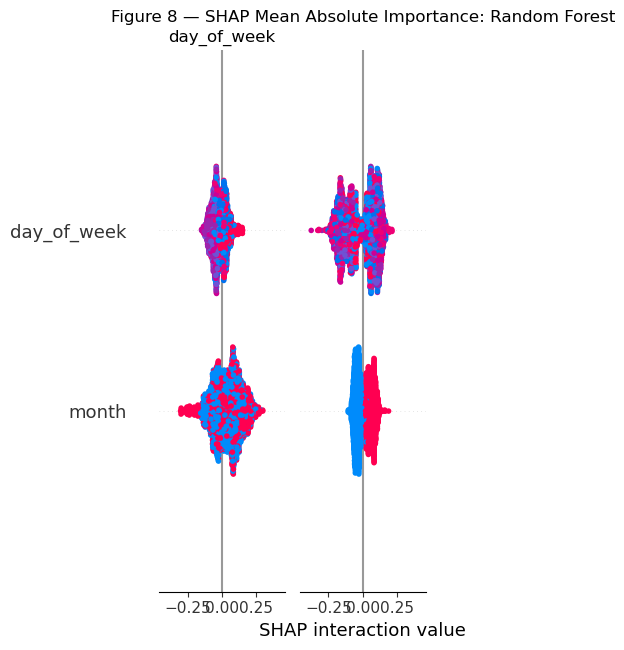

In [24]:
# SHAP Bar Plot — RF (Figure 8)
plot_shap_summary(
    sv_rf, X_test,
    title="Figure 8 — SHAP Mean Absolute Importance: Random Forest",
    plot_type="bar",
    save_path="../outputs/shap_bar_rf.png"
)

### 12.2 SHAP — XGBoost

**Figure 9 — SHAP Summary Plot (XGBoost)**

We repeat the SHAP analysis for XGBoost. Consistent findings across both models strengthen the reliability of the feature importance conclusions.

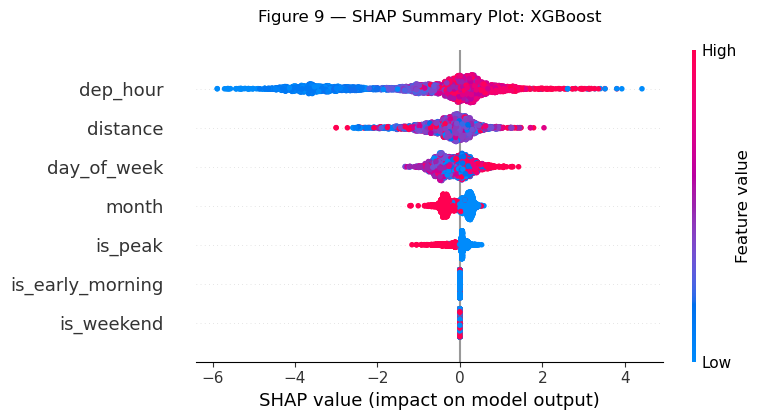

In [25]:
# =====================================================
# SHAP — XGBOOST (Figure 9)
# =====================================================
_, sv_xgb = compute_shap_values(xgb, X_test)

plot_shap_summary(
    sv_xgb, X_test,
    title="Figure 9 — SHAP Summary Plot: XGBoost",
    plot_type="dot",
    save_path="../outputs/shap_summary_xgb.png"
)

**Figure 10 — SHAP Mean Absolute Importance (XGBoost)**

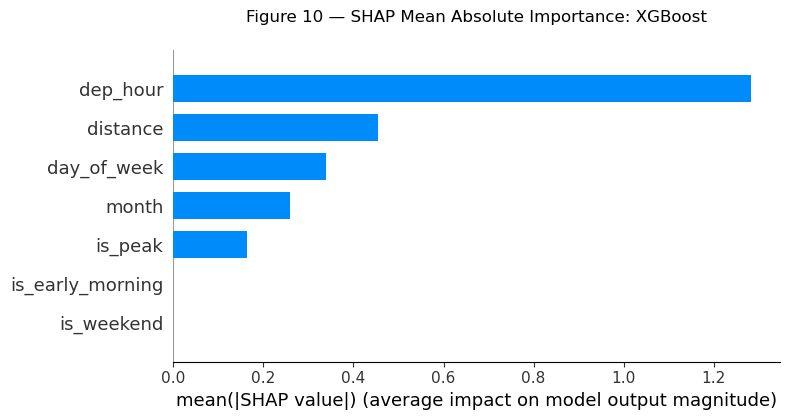

In [26]:
# SHAP Bar Plot — XGBoost (Figure 10)
plot_shap_summary(
    sv_xgb, X_test,
    title="Figure 10 — SHAP Mean Absolute Importance: XGBoost",
    plot_type="bar",
    save_path="../outputs/shap_bar_xgb.png"
)

## 13. Cumulative Gains & Lift

**Figure 11 — Cumulative Gains Curve**

Shows what fraction of delayed flights each model captures when targeting a given proportion of all flights. A steeper curve means the model concentrates delays in its top predictions.

**Figure 12 — Lift by Decile**

Lift measures how much better the model performs vs. random selection per decile. Decile 1 = top 10% most likely delayed. A lift of 2.0 means the model finds twice as many delays as random chance.

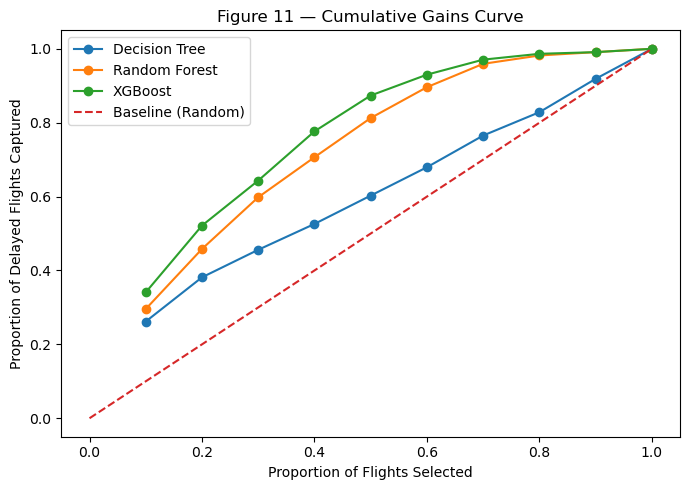

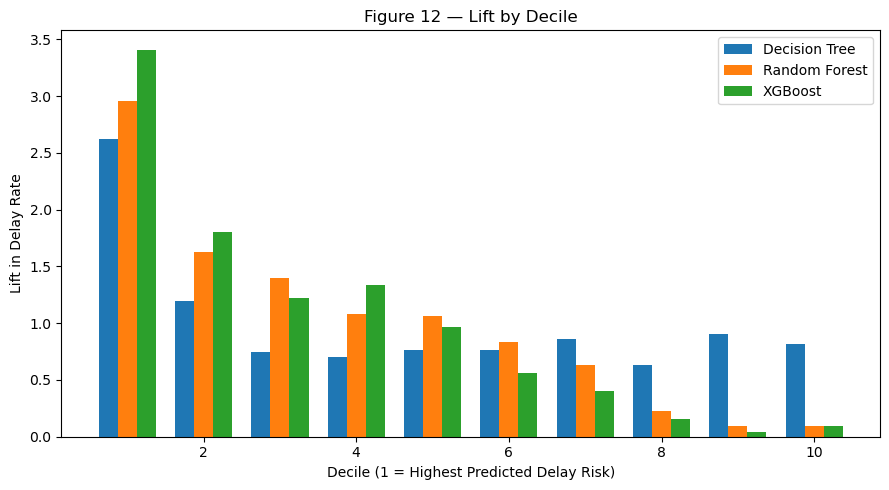

In [27]:
# =====================================================
# CUMULATIVE GAINS & LIFT (Figure 11 & 12)
# =====================================================
dec_dt  = build_decile_summary(y_test, y_prob_dt)
dec_rf  = build_decile_summary(y_test, y_prob_rf)
dec_xgb = build_decile_summary(y_test, y_prob_xgb)

# Figure 11
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dec_dt['cum_pct_flights'],  dec_dt['cum_pct_pos'],  marker='o', label='Decision Tree')
ax.plot(dec_rf['cum_pct_flights'],  dec_rf['cum_pct_pos'],  marker='o', label='Random Forest')
ax.plot(dec_xgb['cum_pct_flights'], dec_xgb['cum_pct_pos'], marker='o', label='XGBoost')
ax.plot([0,1],[0,1], '--', label='Baseline (Random)')
ax.set_xlabel('Proportion of Flights Selected')
ax.set_ylabel('Proportion of Delayed Flights Captured')
ax.set_title('Figure 11 — Cumulative Gains Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/cumulative_gains_comparison.png', dpi=150)
plt.show()

# Figure 12
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dec_dt['decile']  - width, dec_dt['lift'],  width=width, label='Decision Tree')
ax.bar(dec_rf['decile'],           dec_rf['lift'],  width=width, label='Random Forest')
ax.bar(dec_xgb['decile'] + width,  dec_xgb['lift'], width=width, label='XGBoost')
ax.set_xlabel('Decile (1 = Highest Predicted Delay Risk)')
ax.set_ylabel('Lift in Delay Rate')
ax.set_title('Figure 12 — Lift by Decile')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/lift_comparison.png', dpi=150)
plt.show()

## 14. Final Insights — Flight Delay Prediction

### Model Performance

Four models were evaluated on the same held-out test set (see Table 1):

| Model | ROC-AUC (Test) | CV ROC-AUC | Recall | F1 |
|---|---|---|---|---|
| Decision Tree | 0.6151 | 0.6401 | 20.3% | 0.2651 |
| Random Forest | 0.7501 | 0.7689 | 60.1% | 0.3250 |
| Tuned Random Forest | 0.7575 | 0.7897 | 8.1% | 0.1440 |
| **XGBoost** | **0.7891** | **0.8079** | **64.3%** | **0.3587** |

**XGBoost** achieved the best overall discrimination. **Random Forest** is recommended for operational use due to its strong recall and interpretability. The Tuned Random Forest, despite high CV AUC, collapsed recall to 8.1% — capturing fewer than 1 in 10 actual delays, making it unsuitable for operational deployment.

### Class Imbalance

Delayed flights represent only **11.42%** of the dataset — a highly imbalanced problem. Random Forest addressed this via `class_weight='balanced'`; XGBoost via `scale_pos_weight=7.76`. Both strategies significantly improved recall over the Decision Tree baseline. Overall accuracy is misleading in this context; recall and ROC-AUC are the relevant metrics.

### Feature Importance (Figures 6–10)

MDI and SHAP consistently rank `dep_hour` and `distance` as the strongest predictors:
- **Evening departures** correlate with higher delay probability due to accumulated delay propagation throughout the day.
- **Longer distances** slightly reduce delay likelihood, likely due to greater schedule buffer on long-haul routes.
- Binary features (`is_peak`, `is_weekend`, `is_early_morning`) show smaller but consistent contributions across both models.

### Business Interpretation

- Targeting the top 10% highest-risk flights yields a **3.4x lift** (XGBoost) and **2.97x lift** (Random Forest) over random selection.
- Both models can serve as **pre-departure risk scoring tools**, enabling ground teams to prioritize staffing, gates, and equipment proactively.
- Threshold tuning below 0.5 can further increase recall at the cost of additional false alarms, depending on operational tolerance.

### Limitations and Future Work
- Additional features (airline carrier, weather at origin, destination congestion) could substantially improve performance.
- Incorporating other delay types (carrier delay, NAS delay) would generalize the model beyond late aircraft delays.
- Results reflect January–February 2024 only and may not generalize to other seasons.